<a href="https://colab.research.google.com/github/ViniHubb/ADS/blob/main/ADS_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
import os
import kagglehub

print("1. Garantindo acesso ao dataset no disco virtual...")
# Baixa ou localiza o dataset direto na estrutura do Google/Kaggle
caminho_virtual = kagglehub.dataset_download("mkechinov/ecommerce-events-history-in-cosmetics-shop")
print(f"   [OK] Localizado em: {caminho_virtual}")

print("\n2. Criando pastas de resultados...")
os.makedirs("resultados/figuras", exist_ok=True)
print("   [OK] Pastas 'resultados/figuras' prontas.")

1. Garantindo acesso ao dataset no disco virtual...
Using Colab cache for faster access to the 'ecommerce-events-history-in-cosmetics-shop' dataset.
   [OK] Localizado em: /kaggle/input/ecommerce-events-history-in-cosmetics-shop

2. Criando pastas de resultados...
   [OK] Pastas 'resultados/figuras' prontas.


In [27]:
import os
import kagglehub

caminho_virtual = kagglehub.dataset_download("mkechinov/ecommerce-events-history-in-cosmetics-shop")

# Escreve o arquivo config.py apontando direto para a origem virtual
with open("config.py", "w", encoding="utf-8") as f:
    f.write(f"""import os

# Caminhos apontando para a pasta virtual do Kaggle
PASTA_DADOS = "{caminho_virtual}"
CAMINHO_CSV = os.path.join(PASTA_DADOS, "2019-Oct.csv")
PASTA_RESUTADOS = "resultados"
PASTA_FIGURAS = os.path.join(PASTA_RESUTADOS, "figuras")
ARQUIVO_PARAMETROS = os.path.join(PASTA_RESUTADOS, "parametros.json")
ARQUIVO_MES = "2019-Oct.csv"

# Configurações do algoritmo para não estourar a RAM do Colab
CHUNKSIZE = 250000        # Processa em blocos de 250k linhas
SAMPLE_DIVISOR = 10       # Filtra deterministicamente ~10% das sessoes para estudo
SEED = 42

K_MIN = 2
K_MAX = 5
""")

print("Arquivo 'config.py' criado e configurado com sucesso!")

Using Colab cache for faster access to the 'ecommerce-events-history-in-cosmetics-shop' dataset.
Arquivo 'config.py' criado e configurado com sucesso!


In [ ]:
%%writefile etapa2_caracterizacao.py
# -*- coding: utf-8 -*-
"""
etapa2_caracterizacao.py
========================
ETAPA 2 - Caracterizacao da Carga de Trabalho.

Segue a abordagem sistematica da disciplina (context.MD, secao 5.2):
  1. Amostragem dos dados (1 mes, amostra deterministica por sessao);
  2. Sumarizacao estatistica + histogramas;
  3. Construcao das features por sessao;
  4. Transformacao logaritmica + remocao de outliers + padronizacao;
  5. PCA (Analise de Componentes Principais);
  6. Clusterizacao (K-Means) -> perfis de usuario.

Tambem extrai a TAXA DE CHEGADA (lambda) das requisicoes, salva em
resultados/parametros.json para alimentar a etapa 3 (teoria das filas).

Uso:
    python etapa2_caracterizacao.py
"""

import os
import json

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")  # backend sem janela (so salva arquivos)
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

import config


# ---------------------------------------------------------------------------
# Utilitarios
# ---------------------------------------------------------------------------
def preparar_pastas():
    os.makedirs(config.PASTA_FIGURAS, exist_ok=True)


def salvar_figura(nome):
    """Salva a figura atual em resultados/figuras/<nome> e fecha."""
    caminho = os.path.join(config.PASTA_FIGURAS, nome)
    plt.tight_layout()
    plt.savefig(caminho, dpi=120)
    plt.close()
    print(f"   [figura salva] {caminho}")


def titulo(texto):
    print("\n" + "=" * 70)
    print(texto)
    print("=" * 70)


# ---------------------------------------------------------------------------
# Passo 1 - Leitura amostrada (por sessao) + taxa de chegada (lambda)
# ---------------------------------------------------------------------------
def carregar_amostra_e_lambda():
    """
    Le o CSV em chunks. Faz duas coisas em uma unica passada:
      - amostragem deterministica por sessao (sessoes completas);
      - contagem de requisicoes por segundo (para extrair lambda).

    Retorna (df_amostra, lambda_medio, lambda_pico).
    """
    titulo("PASSO 1 - Leitura amostrada do dataset e taxa de chegada (lambda)")
    # No Colab o dataset ja foi baixado via kagglehub nas celulas de setup e o
    # caminho esta em config.CAMINHO_CSV. Apenas validamos que existe.
    if not os.path.exists(config.CAMINHO_CSV):
        raise SystemExit(f"ERRO: arquivo nao encontrado: {config.CAMINHO_CSV}")
    caminho_csv = config.CAMINHO_CSV
    print(f"Arquivo: {caminho_csv}")
    print(f"Amostragem: ~1/{config.SAMPLE_DIVISOR} das sessoes "
          f"(deterministica por user_session)")

    colunas = ["event_time", "event_type", "product_id",
               "brand", "price", "user_id", "user_session"]

    pedacos_amostra = []
    contagem_por_segundo = {}  # timestamp(seg) -> nº de eventos
    total_eventos = 0

    leitor = pd.read_csv(
        caminho_csv,
        usecols=colunas,
        chunksize=config.CHUNKSIZE,
    )

    for i, chunk in enumerate(leitor):
        total_eventos += len(chunk)

        # --- contagem de requisicoes por segundo (lambda) ---
        # event_time vem como "2019-10-01 00:00:00 UTC"; cortamos os 19
        # primeiros caracteres (YYYY-MM-DD HH:MM:SS) e contamos por valor.
        segs = chunk["event_time"].str.slice(0, 19)
        vc = segs.value_counts()
        for ts, n in vc.items():
            contagem_por_segundo[ts] = contagem_por_segundo.get(ts, 0) + int(n)

        # --- amostragem deterministica por sessao ---
        # hash estavel (md5 via pandas) % divisor == 0  -> mantem a sessao.
        s = chunk["user_session"].astype("string").fillna("")
        mascara = (pd.util.hash_pandas_object(s, index=False)
                   % config.SAMPLE_DIVISOR == 0)
        pedacos_amostra.append(chunk[mascara])

        print(f"   chunk {i+1}: {len(chunk):>9,} linhas lidas "
              f"(acumulado {total_eventos:,})")

    df = pd.concat(pedacos_amostra, ignore_index=True)
    print(f"\nTotal de eventos no mes: {total_eventos:,}")
    print(f"Eventos na amostra:      {len(df):,}")

    # lambda em requisicoes por segundo
    contagens = np.array(list(contagem_por_segundo.values()), dtype=float)
    lambda_medio = float(contagens.mean())
    lambda_pico = float(np.percentile(contagens, 99))  # pico robusto (p99)
    print(f"\nTaxa de chegada (todas as requisicoes do mes):")
    print(f"   lambda medio = {lambda_medio:.2f} req/s")
    print(f"   lambda pico  = {lambda_pico:.2f} req/s  (percentil 99 das req/s)")

    return df, lambda_medio, lambda_pico


# ---------------------------------------------------------------------------
# Passo 2 - Sumarizacao estatistica + histogramas
# ---------------------------------------------------------------------------
def sumarizacao_estatistica(df):
    titulo("PASSO 2 - Sumarizacao estatistica")

    # (a) Distribuicao dos tipos de evento
    cont_eventos = df["event_type"].value_counts()
    prop_eventos = (cont_eventos / len(df) * 100).round(2)
    print("\nDistribuicao de event_type (amostra):")
    for tipo in cont_eventos.index:
        print(f"   {tipo:18s} {cont_eventos[tipo]:>9,}  ({prop_eventos[tipo]:5.2f}%)")

    plt.figure(figsize=(7, 4))
    cont_eventos.plot(kind="bar", color="#4C72B0")
    plt.title("Distribuicao de eventos por tipo")
    plt.ylabel("nº de eventos")
    plt.xticks(rotation=20)
    salvar_figura("01_eventos_por_tipo.png")

    # (b) Estatisticas de preco
    preco = df["price"].dropna()
    preco = preco[preco > 0]
    print("\nEstatisticas de price (R$/USD):")
    print(preco.describe().round(2).to_string())

    plt.figure(figsize=(7, 4))
    plt.hist(np.log1p(preco), bins=50, color="#55A868")
    plt.title("Histograma de preco (escala log1p)")
    plt.xlabel("log(1 + price)")
    plt.ylabel("frequencia")
    salvar_figura("02_histograma_preco.png")

    # (c) Eventos por sessao
    eventos_por_sessao = df.groupby("user_session").size()
    print("\nEventos por sessao:")
    print(eventos_por_sessao.describe().round(2).to_string())

    plt.figure(figsize=(7, 4))
    plt.hist(np.log1p(eventos_por_sessao), bins=40, color="#C44E52")
    plt.title("Histograma de eventos por sessao (escala log1p)")
    plt.xlabel("log(1 + nº de eventos na sessao)")
    plt.ylabel("frequencia")
    salvar_figura("03_eventos_por_sessao.png")

    # (d) Sessoes por usuario
    sessoes_por_usuario = df.groupby("user_id")["user_session"].nunique()
    print("\nSessoes por usuario:")
    print(sessoes_por_usuario.describe().round(2).to_string())

    # (e) Top marcas
    top_marcas = df["brand"].value_counts().head(10)
    print("\nTop 10 marcas (por nº de eventos):")
    print(top_marcas.to_string())

    plt.figure(figsize=(7, 4))
    top_marcas.iloc[::-1].plot(kind="barh", color="#8172B3")
    plt.title("Top 10 marcas")
    plt.xlabel("nº de eventos")
    salvar_figura("04_top_marcas.png")


# ---------------------------------------------------------------------------
# Passo 3 - Features por sessao
# ---------------------------------------------------------------------------
def construir_features_sessao(df):
    titulo("PASSO 3 - Construcao das features por sessao")

    df["event_time"] = pd.to_datetime(df["event_time"], format="mixed", utc=True,
                                       errors="coerce")
    # indicadores por tipo de evento
    df["is_view"] = (df["event_type"] == "view").astype(int)
    df["is_cart"] = (df["event_type"] == "cart").astype(int)
    df["is_remove"] = (df["event_type"] == "remove_from_cart").astype(int)
    df["is_purchase"] = (df["event_type"] == "purchase").astype(int)
    # valor gasto = soma do preco apenas dos eventos de compra (vetorizado)
    df["valor_purchase"] = df["price"].where(df["is_purchase"] == 1, 0.0)

    g = df.groupby("user_session")
    feats = pd.DataFrame({
        "n_view": g["is_view"].sum(),
        "n_cart": g["is_cart"].sum(),
        "n_remove": g["is_remove"].sum(),
        "n_purchase": g["is_purchase"].sum(),
        "n_eventos": g.size(),
        "n_produtos": g["product_id"].nunique(),
        "duracao_seg": (g["event_time"].max() - g["event_time"].min())
                       .dt.total_seconds(),
        "valor_compras": g["valor_purchase"].sum(),
        "preco_medio": g["price"].mean(),
    })
    feats = feats.fillna(0.0)
    print(f"Sessoes (linhas) na matriz de features: {len(feats):,}")
    print("\nResumo das features:")
    print(feats.describe().round(2).to_string())
    return feats


# ---------------------------------------------------------------------------
# Passo 4 - Transformacao + outliers + padronizacao
# ---------------------------------------------------------------------------
def preparar_para_pca(feats):
    titulo("PASSO 4 - Transformacao log, remocao de outliers e padronizacao")

    # (a) transformacao logaritmica (reduz assimetria das contagens/valores)
    X = feats.copy()
    for col in X.columns:
        X[col] = np.log1p(X[col].clip(lower=0))

    # (b) remocao de outliers: descarta sessoes acima do percentil 99 do total
    limite = X["n_eventos"].quantile(0.99)
    antes = len(X)
    mascara = X["n_eventos"] <= limite
    X = X[mascara]
    feats_filtrado = feats[mascara]
    print(f"Outliers removidos (n_eventos > p99): {antes - len(X):,} sessoes")
    print(f"Sessoes restantes: {len(X):,}")

    # (c) padronizacao (media 0, desvio 1) - necessaria para PCA/K-Means
    scaler = StandardScaler()
    X_pad = scaler.fit_transform(X.values)
    return X_pad, feats_filtrado


# ---------------------------------------------------------------------------
# Passo 5 - PCA
# ---------------------------------------------------------------------------
def aplicar_pca(X_pad, nomes_features):
    titulo("PASSO 5 - PCA (Analise de Componentes Principais)")

    pca = PCA()
    componentes = pca.fit_transform(X_pad)

    var = pca.explained_variance_ratio_
    var_acum = np.cumsum(var)
    print("\nVariancia explicada por componente:")
    for i, (v, va) in enumerate(zip(var, var_acum), start=1):
        print(f"   PC{i}: {v*100:5.2f}%   (acumulada {va*100:5.2f}%)")

    n80 = int(np.searchsorted(var_acum, 0.80) + 1)
    print(f"\nComponentes para ~80% da variancia: {n80}")

    # Scree plot
    plt.figure(figsize=(7, 4))
    eixo = np.arange(1, len(var) + 1)
    plt.bar(eixo, var * 100, color="#4C72B0", label="individual")
    plt.plot(eixo, var_acum * 100, "o-", color="#C44E52", label="acumulada")
    plt.axhline(80, ls="--", color="gray")
    plt.title("Scree plot - variancia explicada (PCA)")
    plt.xlabel("componente")
    plt.ylabel("% variancia")
    plt.legend()
    salvar_figura("05_pca_scree.png")

    # Cargas (loadings) das 2 primeiras componentes
    print("\nCargas (loadings) PC1 e PC2:")
    cargas = pd.DataFrame(pca.components_[:2].T, index=nomes_features,
                          columns=["PC1", "PC2"]).round(3)
    print(cargas.to_string())

    return componentes, n80


# ---------------------------------------------------------------------------
# Passo 6 - Clusterizacao (K-Means)
# ---------------------------------------------------------------------------
def clusterizar(componentes, n_componentes, feats_filtrado):
    titulo("PASSO 6 - Clusterizacao (K-Means) -> perfis de usuario")

    X = componentes[:, :max(n_componentes, 2)]

    # (a) escolha de k: cotovelo (inercia) + silhueta
    ks = list(range(config.K_MIN, config.K_MAX + 1))
    inercias, silhuetas = [], []
    # silhueta numa subamostra (mais rapido) se base for grande
    if len(X) > 20000:
        rng = np.random.default_rng(config.SEED)
        idx_sil = rng.choice(len(X), 20000, replace=False)
    else:
        idx_sil = np.arange(len(X))

    print("\nBusca de k (cotovelo + silhueta):")
    for k in ks:
        km = KMeans(n_clusters=k, random_state=config.SEED, n_init=10)
        rotulos = km.fit_predict(X)
        inercias.append(km.inertia_)
        sil = silhouette_score(X[idx_sil], rotulos[idx_sil])
        silhuetas.append(sil)
        print(f"   k={k}: inercia={km.inertia_:12.1f}   silhueta={sil:.3f}")

    k_otimo = ks[int(np.argmax(silhuetas))]
    print(f"\nk escolhido (maior silhueta): {k_otimo}")

    plt.figure(figsize=(10, 4))
    plt.subplot(1, 2, 1)
    plt.plot(ks, inercias, "o-", color="#4C72B0")
    plt.title("Metodo do cotovelo")
    plt.xlabel("k"); plt.ylabel("inercia")
    plt.subplot(1, 2, 2)
    plt.plot(ks, silhuetas, "o-", color="#55A868")
    plt.axvline(k_otimo, ls="--", color="gray")
    plt.title("Silhueta")
    plt.xlabel("k"); plt.ylabel("silhueta")
    salvar_figura("06_escolha_k.png")

    # (b) ajuste final
    km = KMeans(n_clusters=k_otimo, random_state=config.SEED, n_init=10)
    rotulos = km.fit_predict(X)

    # (c) scatter PC1 x PC2 colorido por cluster
    plt.figure(figsize=(7, 6))
    sc = plt.scatter(X[:, 0], X[:, 1], c=rotulos, cmap="tab10",
                     s=6, alpha=0.4)
    plt.title(f"Clusters de sessoes (k={k_otimo}) no espaco PCA")
    plt.xlabel("PC1"); plt.ylabel("PC2")
    plt.colorbar(sc, label="cluster")
    salvar_figura("07_clusters_pca.png")

    # (d) interpretacao: medias das features ORIGINAIS por cluster
    resumo = feats_filtrado.copy()
    resumo["cluster"] = rotulos
    perfil = resumo.groupby("cluster").mean().round(2)
    tamanhos = resumo.groupby("cluster").size()
    perfil.insert(0, "n_sessoes", tamanhos)
    perfil.insert(1, "pct", (tamanhos / len(resumo) * 100).round(1))
    print("\nPerfil medio de cada cluster (valores originais):")
    print(perfil.to_string())

    print("\nInterpretacao sugerida (ajuste no relatorio conforme os numeros):")
    for c in perfil.index:
        linha = perfil.loc[c]
        if linha["n_purchase"] >= 0.5:
            tag = "COMPRADORES (alta conversao)"
        elif linha["n_cart"] >= 0.5 and linha["n_purchase"] < 0.5:
            tag = "ABANDONO DE CARRINHO"
        else:
            tag = "VISITANTES / navegacao (views)"
        print(f"   cluster {c}: {tag}  "
              f"[{linha['pct']}% das sessoes]")

    return perfil


# ---------------------------------------------------------------------------
# Salvar parametros para a etapa 3
# ---------------------------------------------------------------------------
def salvar_parametros(lambda_medio, lambda_pico, df_total_eventos):
    params = {
        "lambda_medio_reqs": round(lambda_medio, 4),
        "lambda_pico_reqs": round(lambda_pico, 4),
        "arquivo_mes": config.ARQUIVO_MES,
        "obs": ("lambda em requisicoes/segundo, extraido contando eventos "
                "por segundo no mes inteiro. Cada evento = 1 requisicao HTTP."),
    }
    with open(config.ARQUIVO_PARAMETROS, "w", encoding="utf-8") as f:
        json.dump(params, f, indent=2, ensure_ascii=False)
    print(f"\n[parametros salvos] {config.ARQUIVO_PARAMETROS}")


# ---------------------------------------------------------------------------
# Main
# ---------------------------------------------------------------------------
def main():
    preparar_pastas()

    df, lambda_medio, lambda_pico = carregar_amostra_e_lambda()
    sumarizacao_estatistica(df)
    feats = construir_features_sessao(df)
    X_pad, feats_filtrado = preparar_para_pca(feats)
    componentes, n80 = aplicar_pca(X_pad, list(feats.columns))
    clusterizar(componentes, n80, feats_filtrado)
    salvar_parametros(lambda_medio, lambda_pico, len(df))

    titulo("ETAPA 2 CONCLUIDA")
    print("Figuras em:", config.PASTA_FIGURAS)
    print("Parametros (lambda) em:", config.ARQUIVO_PARAMETROS)
    print("Agora rode:  python etapa3_filas_experimentos.py")


if __name__ == "__main__":
    main()

In [29]:
%run etapa2_caracterizacao.py


PASSO 1 - Leitura amostrada do dataset e taxa de chegada (lambda)
Lendo direto de: /kaggle/input/ecommerce-events-history-in-cosmetics-shop/2019-Oct.csv
Amostragem: Mantendo sessoes completas na proporcao 1/10
   Progresso: 250,000 linhas processadas...
   Progresso: 1,000,000 linhas processadas...
   Progresso: 2,000,000 linhas processadas...
   Progresso: 3,000,000 linhas processadas...
   Progresso: 4,000,000 linhas processadas...

Total de eventos processados no mes: 4,102,283
Eventos retidos na amostra para analise: 409,457
--> Lambda Medio: 2.30 req/s | Lambda Pico (P99): 8.00 req/s

PASSO 2 - Sumarizacao estatistica e Graficos
   [figura salva] resultados/figuras/01_eventos_por_tipo.png
   [figura salva] resultados/figuras/02_histograma_preco.png
   [figura salva] resultados/figuras/03_eventos_por_sessao.png
   [figura salva] resultados/figuras/04_top_marcas.png

PASSO 3 - Engenharia de Features por Sessao
Matriz de features estruturada: 87,431 sessoes exclusivas.

PASSO 4 - Tr


📈 Arquivo gerado: 01_eventos_por_tipo.png


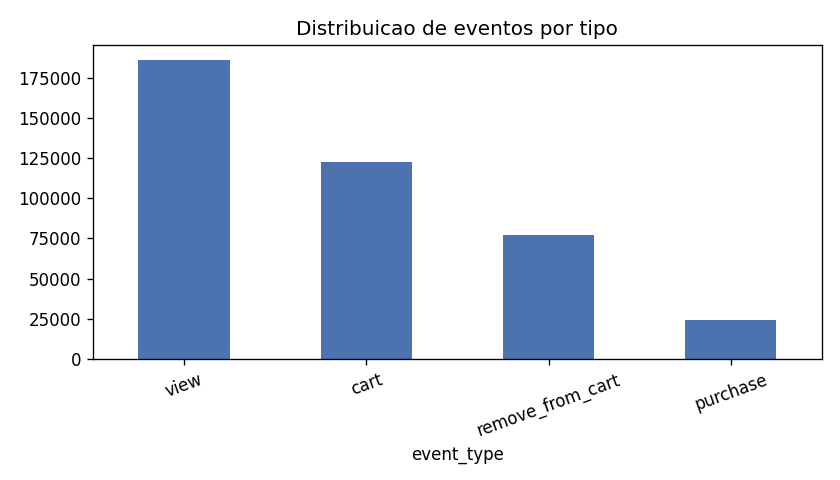


📈 Arquivo gerado: 02_histograma_preco.png


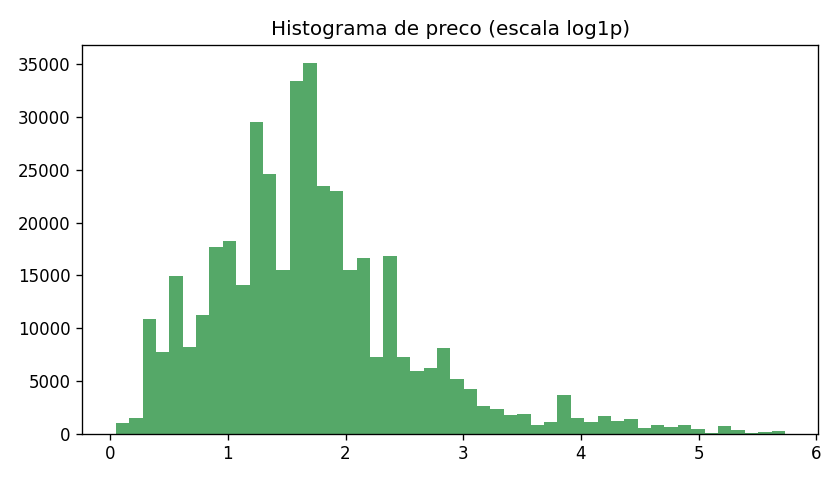


📈 Arquivo gerado: 03_eventos_por_sessao.png


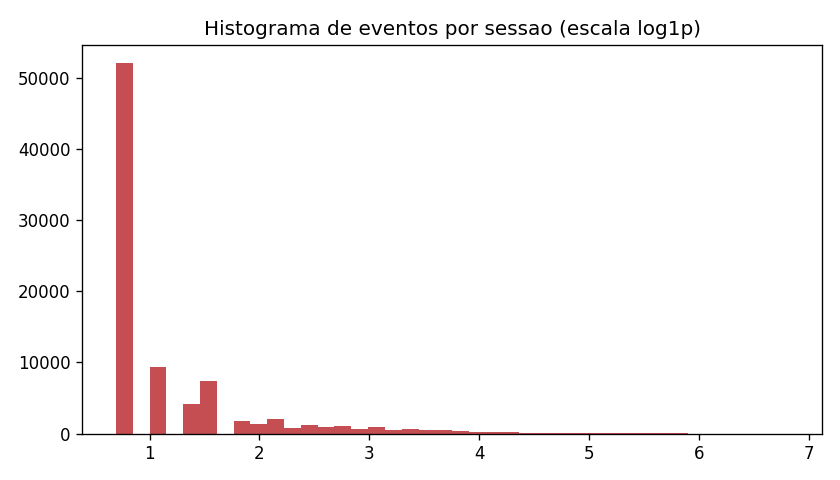


📈 Arquivo gerado: 04_top_marcas.png


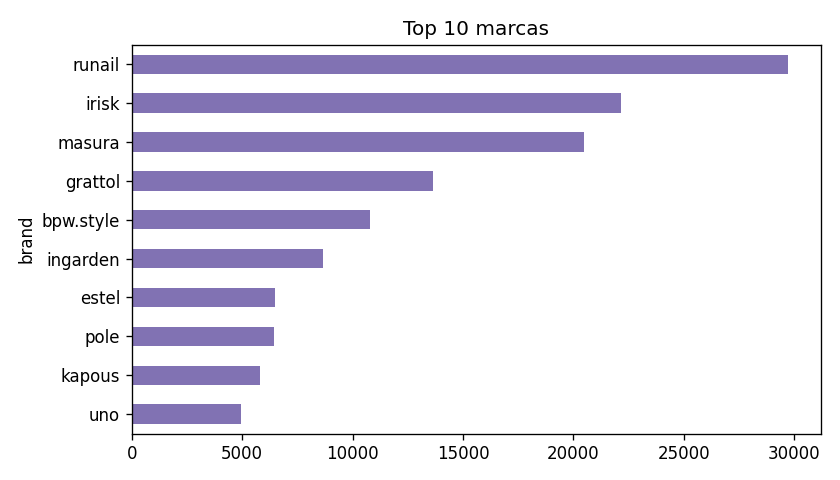


📈 Arquivo gerado: 05_pca_scree.png


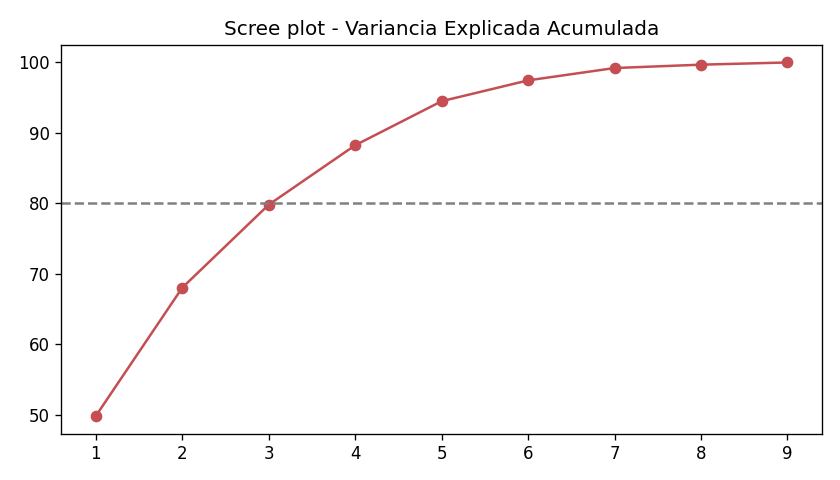


📈 Arquivo gerado: 07_clusters_pca.png


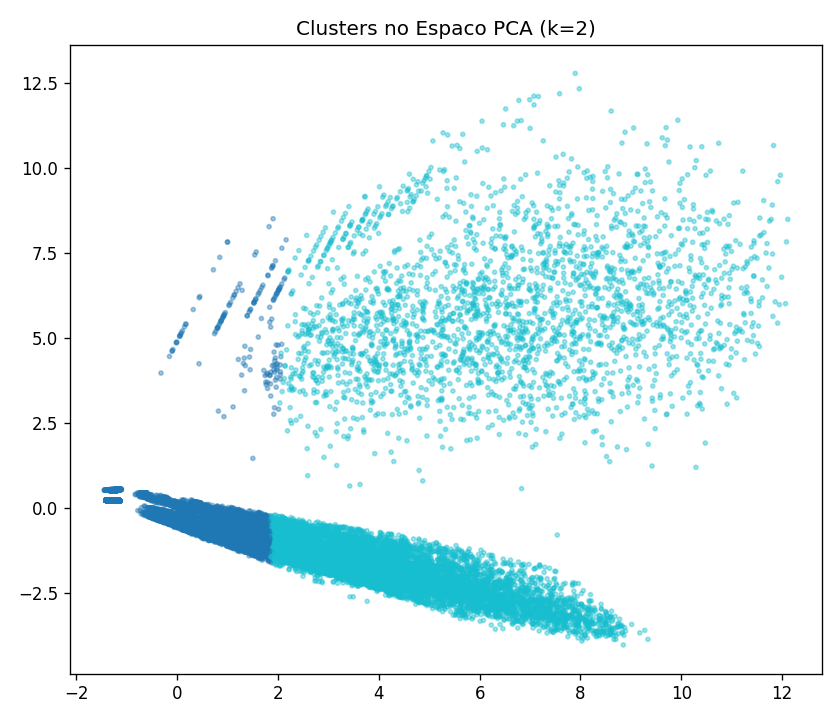

In [30]:
from IPython.display import Image, display
import os

pasta_figuras = "resultados/figuras"
if os.path.exists(pasta_figuras):
    for imagem in sorted(os.listdir(pasta_figuras)):
        print(f"\n📈 Arquivo gerado: {imagem}")
        display(Image(filename=os.path.join(pasta_figuras, imagem)))
else:
    print("Nenhum gráfico encontrado. Ocorreu algum erro na execução?")

import shutil
import os
import sys

print("🧹 Iniciando limpeza...")

# 1. Remover pasta de resultados
if os.path.exists('resultados'):
    shutil.rmtree('resultados')
    print("   [OK] Pasta 'resultados' removida.")

# 2. Remover cache do Python (__pycache__)
for root, dirs, files in os.walk('.', topdown=False):
    for name in dirs:
        if name == '__pycache__':
            shutil.rmtree(os.path.join(root, name))

# 3. Forçar recarregamento de módulos (importante se você alterou o config.py)
if 'config' in sys.modules:
    del sys.modules['config']
    print("   [OK] Cache do módulo 'config' limpo.")

print("\n✨ Limpeza concluída! Você pode rodar as células de configuração e processamento novamente.")